# Codebook-FIGS Interpretability Evaluation

This notebook demonstrates the **Codebook-FIGS interpretability evaluation**, which computes 20 metrics across 7 groups on domain-semantic datasets. It:

1. Re-trains K-size codebook models with the best config (`random_wls`)
2. Extracts codebook directions from trained models
3. Evaluates interpretability via:
   - **Direction Sparsity** (L1 norm, Gini, top-3 concentration)
   - **Domain Alignment** (hit rate against known risk factors)
   - **Usage Distribution** (active size, uniformity)
   - **Complexity Compression** (vs FIGS baseline)
   - **Direction Diversity** (pairwise cosine)
   - **Cross-Fold Stability** (feature overlap, cosine similarity)
   - **Semantic Labels** with interpretability verdicts

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# imodels — NOT on Colab, always install
_pip('imodels==2.0.4')

# Core packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import time
import numpy as np
from typing import List, Dict, Tuple, Optional, Any
from itertools import combinations
import matplotlib.pyplot as plt

## Data Loading

Load the demo dataset (breast cancer WDBC) from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/evaluation_iter3_codebook_figs_i/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  breast_cancer_wdbc: 100 examples


## Configuration

Tunable parameters for the Codebook-FIGS evaluation. Adjust these to control model complexity and evaluation depth.

In [5]:
# ── Codebook-FIGS parameters ──
K = 8                        # codebook size (original: 8)
MAX_RULES = 12               # max tree rules (original: 12)
N_FOLDS = 5                  # cross-validation folds (original: 5)
N_ALTERNATION_ROUNDS = 5     # alternation rounds (original: 5)
MIN_SAMPLES_LEAF = 5         # min samples per leaf (original: 5)

# ── Evaluation config ──
INIT_STRATEGY = "random"
REFINE_STRATEGY = "wls"

# ── Domain risk factors (breast cancer WDBC) ──
DOMAIN_FACTORS = {
    "breast_cancer_wdbc": [
        "worst radius", "worst perimeter", "worst area",
        "worst concave points", "worst concavity",
        "mean radius", "mean perimeter", "mean area",
        "mean concave points", "mean concavity",
        "mean compactness", "worst compactness",
    ],
}

## Parse Dataset

Convert the raw JSON examples into numpy arrays for training.

In [6]:
def load_datasets(raw_data, target_names=None):
    """Load datasets from the raw JSON structure."""
    datasets = {}
    for group in raw_data["datasets"]:
        name = group["dataset"]
        if name.endswith("_mini"):
            continue
        if target_names and name not in target_names:
            continue
        examples = group["examples"]
        first = examples[0]
        task_type = first["metadata_task_type"]
        n_features = first.get("metadata_n_features", None)
        feature_names = first.get("metadata_feature_names", [])

        X_list, y_list, fold_list = [], [], []
        for ex in examples:
            X_list.append(json.loads(ex["input"]))
            y_list.append(float(ex["output"]))
            fold_list.append(int(ex["metadata_fold"]))

        X = np.array(X_list, dtype=np.float64)
        y = np.array(y_list, dtype=np.float64)
        folds = np.array(fold_list, dtype=np.int32)

        if n_features is None:
            n_features = X.shape[1]

        datasets[name] = {
            "X": X, "y": y, "folds": folds,
            "task_type": task_type,
            "feature_names": feature_names,
            "n_features": n_features,
        }
        print(f"  {name}: {X.shape[0]} samples, {X.shape[1]} features, {task_type}")
    return datasets

datasets = load_datasets(data)
ds_name = list(datasets.keys())[0]
ds_data = datasets[ds_name]
print(f"\nUsing dataset: {ds_name}")

  breast_cancer_wdbc: 100 samples, 30 features, classification

Using dataset: breast_cancer_wdbc


## Codebook-FIGS Core Model

The core model: FIGS with oblique splits constrained to a shared codebook of K directions.

In [7]:
class Node:
    """Tree node for Codebook-FIGS."""
    __slots__ = [
        "codebook_idx", "weights", "threshold", "value",
        "idxs", "left", "right", "left_temp", "right_temp",
        "impurity_reduction", "is_root", "tree_num", "depth", "n_samples",
    ]

    def __init__(self) -> None:
        self.codebook_idx: Optional[int] = None
        self.weights: Optional[np.ndarray] = None
        self.threshold: Optional[float] = None
        self.value: float = 0.0
        self.idxs: Optional[np.ndarray] = None
        self.left: Optional["Node"] = None
        self.right: Optional["Node"] = None
        self.left_temp: Optional["Node"] = None
        self.right_temp: Optional["Node"] = None
        self.impurity_reduction: Optional[float] = None
        self.is_root: bool = False
        self.tree_num: int = -1
        self.depth: int = 0
        self.n_samples: int = 0


def init_codebook_pca(X_train: np.ndarray, K: int) -> np.ndarray:
    from sklearn.decomposition import PCA
    X_centered = X_train - X_train.mean(axis=0)
    K_actual = min(K, min(X_train.shape[0], X_train.shape[1]))
    pca = PCA(n_components=K_actual)
    pca.fit(X_centered)
    C = pca.components_.copy()
    if K_actual < K:
        rng = np.random.RandomState(42)
        extra = rng.randn(K - K_actual, X_train.shape[1])
        extra = extra / (np.linalg.norm(extra, axis=1, keepdims=True) + 1e-12)
        C = np.vstack([C, extra])
    norms = np.linalg.norm(C, axis=1, keepdims=True)
    C = C / np.maximum(norms, 1e-12)
    return C


def init_codebook_random(X_train: np.ndarray, K: int, random_state: int = 42) -> np.ndarray:
    rng = np.random.RandomState(random_state)
    C = rng.randn(K, X_train.shape[1])
    C = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-12)
    return C


def find_best_codebook_split(
    X: np.ndarray,
    y_residuals: np.ndarray,
    idxs: np.ndarray,
    codebook: np.ndarray,
    min_samples_leaf: int = 5,
    quantile_threshold: int = 5000,
) -> Tuple[Optional[int], Optional[float], float, Optional[np.ndarray], Optional[np.ndarray]]:
    node_indices = np.where(idxs)[0]
    n_node = len(node_indices)

    if n_node < 2 * min_samples_leaf:
        return None, None, -np.inf, None, None

    X_node = X[node_indices]
    y_node = y_residuals[node_indices]
    parent_var = np.var(y_node) * n_node

    best_k: Optional[int] = None
    best_threshold: Optional[float] = None
    best_reduction = -np.inf
    K_val = codebook.shape[0]

    use_quantiles = n_node > quantile_threshold
    n_quantiles = 100

    for k in range(K_val):
        proj = X_node @ codebook[k]
        order = np.argsort(proj)
        sorted_proj = proj[order]
        sorted_y = y_node[order]

        cum_sum = np.cumsum(sorted_y)
        cum_sq_sum = np.cumsum(sorted_y ** 2)
        total_sum = cum_sum[-1]
        total_sq_sum = cum_sq_sum[-1]

        if use_quantiles:
            positions = np.linspace(
                min_samples_leaf - 1,
                n_node - min_samples_leaf - 1,
                min(n_quantiles, n_node - 2 * min_samples_leaf),
            ).astype(int)
            positions = np.unique(positions)
        else:
            positions = np.arange(min_samples_leaf - 1, n_node - min_samples_leaf)

        for i in positions:
            if i + 1 < n_node and sorted_proj[i] == sorted_proj[i + 1]:
                continue

            n_left = i + 1
            n_right = n_node - n_left

            left_sum = cum_sum[i]
            right_sum = total_sum - left_sum

            left_mse = cum_sq_sum[i] - (left_sum ** 2) / n_left
            right_mse = (total_sq_sum - cum_sq_sum[i]) - (right_sum ** 2) / n_right

            reduction = parent_var - left_mse - right_mse

            if reduction > best_reduction:
                best_reduction = reduction
                best_k = k
                if i + 1 < n_node:
                    best_threshold = (sorted_proj[i] + sorted_proj[i + 1]) / 2.0
                else:
                    best_threshold = sorted_proj[i]

    if best_k is None:
        return None, None, -np.inf, None, None

    full_proj = X @ codebook[best_k]
    idxs_left = idxs & (full_proj <= best_threshold)
    idxs_right = idxs & (full_proj > best_threshold)

    return best_k, best_threshold, best_reduction, idxs_left, idxs_right


def effective_rank(C: np.ndarray, eps: float = 1e-12) -> float:
    s = np.linalg.svd(C, compute_uv=False)
    s = s[s > eps]
    if len(s) == 0:
        return 0.0
    p = s / np.sum(s)
    entropy = -np.sum(p * np.log(p + 1e-30))
    return float(np.exp(entropy))


print("Node and helper functions defined.")

Node and helper functions defined.


## CodebookFIGS Class

The full model class with alternating optimization: grow trees using codebook splits, then refine codebook directions via WLS.

In [8]:
class CodebookFIGS:
    """Codebook-FIGS: FIGS with oblique splits constrained to a shared codebook."""

    def __init__(
        self,
        K: int = 8,
        max_rules: int = 12,
        max_trees: Optional[int] = None,
        min_impurity_decrease: float = 0.0,
        max_depth: Optional[int] = None,
        n_alternation_rounds: int = 5,
        init_strategy: str = "pca",
        refine_strategy: str = "wls",
        random_state: int = 42,
        min_samples_leaf: int = 5,
    ) -> None:
        self.K = K
        self.max_rules = max_rules
        self.max_trees = max_trees
        self.min_impurity_decrease = min_impurity_decrease
        self.max_depth = max_depth
        self.n_alternation_rounds = n_alternation_rounds
        self.init_strategy = init_strategy
        self.refine_strategy = refine_strategy
        self.random_state = random_state
        self.min_samples_leaf = min_samples_leaf

        self.trees_: List[Node] = []
        self.codebook_: Optional[np.ndarray] = None
        self.scaler_: Any = None
        self.task_type_: str = "classification"
        self.complexity_: int = 0
        self.history_: Dict[str, list] = {}
        self.converged_at_round_: int = 0

    def fit(self, X: np.ndarray, y: np.ndarray, task_type: str = "classification") -> "CodebookFIGS":
        from sklearn.preprocessing import StandardScaler

        n_samples, n_features = X.shape
        self.task_type_ = task_type

        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X)

        if self.init_strategy == "pca":
            self.codebook_ = init_codebook_pca(X_scaled, self.K)
        elif self.init_strategy == "random":
            self.codebook_ = init_codebook_random(X_scaled, self.K, self.random_state)
        else:
            raise ValueError(f"Unknown init_strategy: {self.init_strategy}")

        self.history_ = {
            "codebooks": [], "train_losses": [], "eranks": [],
            "n_splits": [], "accuracies": [],
        }

        initial_loss: Optional[float] = None

        for round_idx in range(self.n_alternation_rounds):
            self._grow_trees(X_scaled, y)

            preds = self._predict_raw(X_scaled)
            loss = float(np.mean((y - preds) ** 2))

            if task_type == "classification":
                acc = float(np.mean((preds >= 0.5).astype(int) == y.astype(int)))
                self.history_["accuracies"].append(acc)
            else:
                ss_res = np.sum((y - preds) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                r2 = 1.0 - ss_res / max(ss_tot, 1e-12)
                self.history_["accuracies"].append(float(r2))

            self.history_["train_losses"].append(loss)
            self.history_["codebooks"].append(self.codebook_.copy())
            self.history_["eranks"].append(effective_rank(self.codebook_))
            self.history_["n_splits"].append(self.complexity_)

            if initial_loss is None:
                initial_loss = loss

            if round_idx < self.n_alternation_rounds - 1:
                if self.refine_strategy == "wls":
                    self._refine_codebook_wls(X_scaled, y)

                self._check_codebook_collapse()

                if len(self.history_["train_losses"]) >= 2 and initial_loss is not None:
                    loss_change = abs(
                        self.history_["train_losses"][-1] - self.history_["train_losses"][-2]
                    )
                    if initial_loss > 0 and loss_change < 0.01 * initial_loss:
                        self.converged_at_round_ = round_idx + 1
                        break

        if not hasattr(self, "converged_at_round_") or self.converged_at_round_ == 0:
            self.converged_at_round_ = len(self.history_["train_losses"])

        return self

    def _grow_trees(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples = X.shape[0]
        self.trees_ = []
        self.complexity_ = 0
        y_pred_per_tree: Dict[int, np.ndarray] = {}

        all_idxs = np.ones(n_samples, dtype=bool)
        initial_residuals = y.copy()

        best_k, best_t, best_red, idxs_l, idxs_r = find_best_codebook_split(
            X, initial_residuals, all_idxs, self.codebook_, self.min_samples_leaf,
        )

        if best_k is None:
            root = Node()
            root.is_root = True
            root.tree_num = 0
            root.idxs = all_idxs
            root.value = float(np.mean(y))
            root.n_samples = n_samples
            self.trees_.append(root)
            y_pred_per_tree[0] = np.full(n_samples, root.value)
            return

        root = Node()
        root.is_root = True
        root.tree_num = -1
        root.idxs = all_idxs
        root.value = float(np.mean(y))
        root.impurity_reduction = best_red
        root.codebook_idx = best_k
        root.weights = self.codebook_[best_k].copy()
        root.threshold = best_t
        root.depth = 0
        root.n_samples = n_samples

        root.left_temp = Node()
        root.left_temp.idxs = idxs_l
        root.left_temp.value = float(np.mean(initial_residuals[idxs_l])) if idxs_l.sum() > 0 else 0.0
        root.left_temp.n_samples = int(idxs_l.sum())
        root.left_temp.depth = 1

        root.right_temp = Node()
        root.right_temp.idxs = idxs_r
        root.right_temp.value = float(np.mean(initial_residuals[idxs_r])) if idxs_r.sum() > 0 else 0.0
        root.right_temp.n_samples = int(idxs_r.sum())
        root.right_temp.depth = 1

        potential_splits: List[Node] = [root]
        max_new_trees_per_round = 10

        while potential_splits and self.complexity_ < self.max_rules:
            potential_splits.sort(
                key=lambda n: n.impurity_reduction if n.impurity_reduction is not None else -np.inf,
                reverse=True,
            )
            best_node = potential_splits.pop(0)

            if best_node.impurity_reduction is None or best_node.impurity_reduction < self.min_impurity_decrease:
                break

            if self.max_depth is not None and best_node.depth >= self.max_depth:
                continue

            if best_node.is_root:
                if self.max_trees is not None and len(self.trees_) >= self.max_trees:
                    continue
                if len(self.trees_) >= max_new_trees_per_round:
                    continue
                best_node.tree_num = len(self.trees_)
                self.trees_.append(best_node)
                y_pred_per_tree[best_node.tree_num] = np.full(n_samples, best_node.value)

            self.complexity_ += 1
            best_node.left = best_node.left_temp
            best_node.right = best_node.right_temp
            best_node.left.tree_num = best_node.tree_num
            best_node.right.tree_num = best_node.tree_num
            best_node.left_temp = None
            best_node.right_temp = None

            tree_root = self.trees_[best_node.tree_num]
            y_pred_per_tree[best_node.tree_num] = self._predict_tree(tree_root, X)

            for child in [best_node.left, best_node.right]:
                if child.n_samples < 2 * self.min_samples_leaf:
                    continue

                t = child.tree_num
                y_residual = y.copy()
                for other_t, pred in y_pred_per_tree.items():
                    if other_t != t:
                        y_residual -= pred

                bk, bt, br, il, ir = find_best_codebook_split(
                    X, y_residual, child.idxs, self.codebook_, self.min_samples_leaf,
                )

                if bk is not None and br > self.min_impurity_decrease:
                    child.codebook_idx = bk
                    child.weights = self.codebook_[bk].copy()
                    child.threshold = bt
                    child.impurity_reduction = br

                    child.left_temp = Node()
                    child.left_temp.idxs = il
                    child.left_temp.value = float(np.mean(y_residual[il])) if il.sum() > 0 else 0.0
                    child.left_temp.n_samples = int(il.sum())
                    child.left_temp.depth = child.depth + 1

                    child.right_temp = Node()
                    child.right_temp.idxs = ir
                    child.right_temp.value = float(np.mean(y_residual[ir])) if ir.sum() > 0 else 0.0
                    child.right_temp.n_samples = int(ir.sum())
                    child.right_temp.depth = child.depth + 1

                    potential_splits.append(child)

            if len(self.trees_) < max_new_trees_per_round:
                y_total_pred = np.zeros(n_samples)
                for pred in y_pred_per_tree.values():
                    y_total_pred += pred
                y_res_new = y - y_total_pred

                bk, bt, br, il, ir = find_best_codebook_split(
                    X, y_res_new, np.ones(n_samples, dtype=bool), self.codebook_, self.min_samples_leaf,
                )

                if bk is not None and br > self.min_impurity_decrease:
                    new_root = Node()
                    new_root.is_root = True
                    new_root.tree_num = -1
                    new_root.idxs = np.ones(n_samples, dtype=bool)
                    new_root.value = float(np.mean(y_res_new))
                    new_root.impurity_reduction = br
                    new_root.codebook_idx = bk
                    new_root.weights = self.codebook_[bk].copy()
                    new_root.threshold = bt
                    new_root.depth = 0
                    new_root.n_samples = n_samples

                    new_root.left_temp = Node()
                    new_root.left_temp.idxs = il
                    new_root.left_temp.value = float(np.mean(y_res_new[il])) if il.sum() > 0 else 0.0
                    new_root.left_temp.n_samples = int(il.sum())
                    new_root.left_temp.depth = 1

                    new_root.right_temp = Node()
                    new_root.right_temp.idxs = ir
                    new_root.right_temp.value = float(np.mean(y_res_new[ir])) if ir.sum() > 0 else 0.0
                    new_root.right_temp.n_samples = int(ir.sum())
                    new_root.right_temp.depth = 1

                    potential_splits.append(new_root)

    def _predict_tree(self, root: Node, X: np.ndarray) -> np.ndarray:
        preds = np.full(X.shape[0], root.value)
        if root.left is not None and root.right is not None:
            proj = X @ root.weights
            left_mask = proj <= root.threshold
            right_mask = ~left_mask
            left_preds = self._predict_tree(root.left, X)
            right_preds = self._predict_tree(root.right, X)
            preds[left_mask] = left_preds[left_mask]
            preds[right_mask] = right_preds[right_mask]
        return preds

    def _predict_raw(self, X: np.ndarray) -> np.ndarray:
        if not self.trees_:
            return np.zeros(X.shape[0])
        preds = np.zeros(X.shape[0])
        for tree in self.trees_:
            preds += self._predict_tree(tree, X)
        return preds

    def predict(self, X_raw: np.ndarray) -> np.ndarray:
        X = self.scaler_.transform(X_raw)
        raw = self._predict_raw(X)
        if self.task_type_ == "classification":
            return (raw >= 0.5).astype(int)
        return raw

    def _collect_nodes_with_codebook_idx(
        self, node: Optional[Node], k: int, result_list: List[Node],
    ) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            if node.codebook_idx == k:
                result_list.append(node)
            self._collect_nodes_with_codebook_idx(node.left, k, result_list)
            self._collect_nodes_with_codebook_idx(node.right, k, result_list)

    def _refine_codebook_wls(self, X: np.ndarray, y: np.ndarray) -> None:
        K_val = self.codebook_.shape[0]
        n_features = self.codebook_.shape[1]

        for k in range(K_val):
            nodes_k: List[Node] = []
            for tree in self.trees_:
                self._collect_nodes_with_codebook_idx(tree, k, nodes_k)

            if len(nodes_k) == 0:
                rng = np.random.RandomState(self.random_state + k)
                self.codebook_[k] = rng.randn(n_features)
                self.codebook_[k] /= np.linalg.norm(self.codebook_[k]) + 1e-12
                continue

            all_X_pooled: List[np.ndarray] = []
            all_y_residual_pooled: List[np.ndarray] = []

            for node in nodes_k:
                y_res = y.copy()
                for t_idx, tree in enumerate(self.trees_):
                    if t_idx != node.tree_num:
                        y_res -= self._predict_tree(tree, X)
                node_mask = node.idxs
                all_X_pooled.append(X[node_mask])
                all_y_residual_pooled.append(y_res[node_mask])

            X_pool = np.vstack(all_X_pooled)
            y_pool = np.concatenate(all_y_residual_pooled)

            direction = X_pool.T @ y_pool
            norm = np.linalg.norm(direction)
            if norm > 1e-12:
                self.codebook_[k] = direction / norm

    def _check_codebook_collapse(self) -> int:
        from sklearn.metrics.pairwise import cosine_similarity
        K_val = self.codebook_.shape[0]
        n_features = self.codebook_.shape[1]
        cos_sim = np.abs(cosine_similarity(self.codebook_))
        np.fill_diagonal(cos_sim, 0.0)
        n_collapses = 0
        for i in range(K_val):
            for j in range(i + 1, K_val):
                if cos_sim[i, j] > 0.99:
                    rng = np.random.RandomState(self.random_state + 100 + j)
                    self.codebook_[j] = rng.randn(n_features)
                    self.codebook_[j] /= np.linalg.norm(self.codebook_[j]) + 1e-12
                    n_collapses += 1
        return n_collapses

    def get_node_codebook_usage(self) -> Dict[int, int]:
        """Count how many split nodes use each codebook entry."""
        usage: Dict[int, int] = {}
        for tree in self.trees_:
            self._count_usage(tree, usage)
        return usage

    def _count_usage(self, node: Optional[Node], usage: Dict[int, int]) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            idx = node.codebook_idx
            if idx is not None:
                usage[idx] = usage.get(idx, 0) + 1
            self._count_usage(node.left, usage)
            self._count_usage(node.right, usage)


print("CodebookFIGS class defined.")

CodebookFIGS class defined.


## Metric Computation Functions

Functions for computing all 7 groups of interpretability metrics: sparsity, domain alignment, usage, complexity, diversity, cross-fold stability, and semantic labels.

In [9]:
def align_codebooks_hungarian(
    C_ref: np.ndarray, C_target: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    from scipy.optimize import linear_sum_assignment
    from sklearn.metrics.pairwise import cosine_similarity

    cos_sim = cosine_similarity(C_ref, C_target)
    abs_cos_sim = np.abs(cos_sim)
    row_ind, col_ind = linear_sum_assignment(abs_cos_sim, maximize=True)

    C_aligned = C_target[col_ind].copy()
    matched_sims = []
    for i in range(len(row_ind)):
        sim = cos_sim[row_ind[i], col_ind[i]]
        matched_sims.append(abs(sim))
        if sim < 0:
            C_aligned[i] *= -1

    return C_aligned, col_ind, np.array(matched_sims)


def _gini_coefficient(values: np.ndarray) -> float:
    """Compute Gini coefficient of a distribution."""
    v = np.sort(np.abs(values))
    n = len(v)
    if n == 0 or np.sum(v) < 1e-12:
        return 0.0
    index = np.arange(1, n + 1)
    return float((2.0 * np.sum(index * v) / (n * np.sum(v))) - (n + 1.0) / n)


def compute_sparsity_metrics(codebook: np.ndarray) -> Dict[str, Any]:
    """Group 1: Direction sparsity metrics for a codebook [K, d]."""
    K_val, d = codebook.shape
    results = {
        "per_direction_l1_norm": [], "per_direction_n_active": [],
        "per_direction_top3_concentration": [], "per_direction_gini": [],
    }
    for k in range(K_val):
        w = codebook[k]
        abs_w = np.abs(w)
        results["per_direction_l1_norm"].append(float(np.sum(abs_w)))
        results["per_direction_n_active"].append(int(np.sum(abs_w > 0.1)))
        sorted_abs = np.sort(abs_w)[::-1]
        total_abs = np.sum(abs_w) + 1e-12
        results["per_direction_top3_concentration"].append(float(np.sum(sorted_abs[:3]) / total_abs))
        results["per_direction_gini"].append(_gini_coefficient(abs_w))
    results["mean_l1_norm"] = float(np.mean(results["per_direction_l1_norm"]))
    results["mean_n_active"] = float(np.mean(results["per_direction_n_active"]))
    results["mean_top3_concentration"] = float(np.mean(results["per_direction_top3_concentration"]))
    results["mean_gini"] = float(np.mean(results["per_direction_gini"]))
    return results


def compute_domain_alignment(
    codebook: np.ndarray, feature_names: List[str], domain_factors: List[str],
) -> Dict[str, Any]:
    """Group 2: Domain alignment metrics."""
    K_val, d = codebook.shape
    domain_indices = set()
    for i, fname in enumerate(feature_names):
        if fname in domain_factors:
            domain_indices.add(i)

    results = {
        "per_direction_top3_hit_rate": [], "per_direction_top5_hit_rate": [],
        "per_direction_weighted_alignment": [],
    }
    for k in range(K_val):
        abs_w = np.abs(codebook[k])
        sorted_idx = np.argsort(abs_w)[::-1]
        top3_idx = sorted_idx[:3]
        hits_3 = sum(1 for i in top3_idx if i in domain_indices)
        results["per_direction_top3_hit_rate"].append(hits_3 / 3.0)
        top5_idx = sorted_idx[:5]
        hits_5 = sum(1 for i in top5_idx if i in domain_indices)
        results["per_direction_top5_hit_rate"].append(hits_5 / 5.0)
        total_weight = np.sum(abs_w) + 1e-12
        domain_weight = sum(abs_w[i] for i in range(d) if i in domain_indices)
        results["per_direction_weighted_alignment"].append(float(domain_weight / total_weight))
    results["mean_top3_hit_rate"] = float(np.mean(results["per_direction_top3_hit_rate"]))
    results["mean_top5_hit_rate"] = float(np.mean(results["per_direction_top5_hit_rate"]))
    results["mean_weighted_alignment"] = float(np.mean(results["per_direction_weighted_alignment"]))
    return results


def compute_usage_distribution(model: CodebookFIGS, K_val: int) -> Dict[str, Any]:
    """Group 3: Direction usage distribution."""
    usage = model.get_node_codebook_usage()
    counts = np.array([usage.get(k, 0) for k in range(K_val)], dtype=np.float64)
    total_splits = int(np.sum(counts))
    active_size = int(np.sum(counts > 0))
    if total_splits > 0 and active_size > 0:
        p = counts / np.sum(counts)
        p = p[p > 0]
        entropy = -np.sum(p * np.log2(p + 1e-30))
        max_entropy = np.log2(K_val)
        uniformity = float(entropy / max_entropy) if max_entropy > 0 else 0.0
    else:
        entropy = 0.0
        uniformity = 0.0
    return {
        "usage_counts": counts.tolist(), "total_splits": total_splits,
        "active_codebook_size": active_size, "usage_entropy": float(entropy),
        "usage_uniformity": uniformity,
    }


def compute_complexity_comparison(
    codebook_active_size: int, total_splits: int, erank: float, figs_unique_features: int,
) -> Dict[str, Any]:
    """Group 4: Interpretability complexity comparison."""
    compression_ratio = total_splits / max(codebook_active_size, 1)
    return {
        "figs_baseline_unique_features": figs_unique_features,
        "active_codebook_size": codebook_active_size,
        "compression_ratio": float(compression_ratio),
        "effective_rank": float(erank),
    }


def compute_direction_diversity(codebook: np.ndarray) -> Dict[str, Any]:
    """Group 5: Within-dataset direction diversity."""
    from sklearn.metrics.pairwise import cosine_similarity
    K_val = codebook.shape[0]
    if K_val < 2:
        return {"mean_pairwise_abs_cos": 0.0, "max_pairwise_abs_cos": 0.0, "diversity_score": 1.0}
    cos_sim = cosine_similarity(codebook)
    abs_cos = np.abs(cos_sim)
    np.fill_diagonal(abs_cos, 0.0)
    upper_idx = np.triu_indices(K_val, k=1)
    pairwise_abs = abs_cos[upper_idx]
    mean_abs = float(np.mean(pairwise_abs))
    max_abs = float(np.max(pairwise_abs))
    diversity = 1.0 - mean_abs
    redundant_pairs = []
    for i, j in zip(upper_idx[0], upper_idx[1]):
        if abs_cos[i, j] > 0.9:
            redundant_pairs.append((int(i), int(j), float(abs_cos[i, j])))
    return {
        "mean_pairwise_abs_cos": mean_abs, "max_pairwise_abs_cos": max_abs,
        "diversity_score": float(diversity), "n_redundant_pairs": len(redundant_pairs),
        "redundant_pairs": redundant_pairs,
    }


def compute_cross_fold_stability(
    codebooks: List[np.ndarray], feature_names: List[str],
) -> Dict[str, Any]:
    """Group 6: Cross-fold semantic stability."""
    if len(codebooks) < 2:
        K_val = codebooks[0].shape[0]
        return {
            "mean_top3_feature_overlap": 1.0, "mean_sign_consistency": 1.0,
            "mean_cosine_stability": 1.0,
            "per_direction_top3_overlap": [1.0] * K_val,
            "per_direction_sign_consistency": [1.0] * K_val,
            "per_direction_cosine_stability": [1.0] * K_val,
        }
    C_ref = codebooks[0]
    K_val = C_ref.shape[0]
    aligned_codebooks = [C_ref]
    for fold_idx in range(1, len(codebooks)):
        C_aligned, _, sims = align_codebooks_hungarian(C_ref, codebooks[fold_idx])
        aligned_codebooks.append(C_aligned)

    per_dir_top3_overlaps = [[] for _ in range(K_val)]
    per_dir_sign_consistencies = [[] for _ in range(K_val)]
    per_dir_cosine_sims = [[] for _ in range(K_val)]
    n_folds = len(aligned_codebooks)
    for i_fold in range(n_folds):
        for j_fold in range(i_fold + 1, n_folds):
            for k in range(K_val):
                w_i = aligned_codebooks[i_fold][k]
                w_j = aligned_codebooks[j_fold][k]
                top3_i = set(np.argsort(np.abs(w_i))[-3:])
                top3_j = set(np.argsort(np.abs(w_j))[-3:])
                overlap = len(top3_i & top3_j) / 3.0
                per_dir_top3_overlaps[k].append(overlap)
                n_features = len(w_i)
                sign_match = np.sum(np.sign(w_i) == np.sign(w_j)) / n_features
                per_dir_sign_consistencies[k].append(float(sign_match))
                cos_sim = np.dot(w_i, w_j) / (np.linalg.norm(w_i) * np.linalg.norm(w_j) + 1e-12)
                per_dir_cosine_sims[k].append(float(np.abs(cos_sim)))

    per_dir_overlap_mean = [float(np.mean(x)) if x else 0.0 for x in per_dir_top3_overlaps]
    per_dir_sign_mean = [float(np.mean(x)) if x else 0.0 for x in per_dir_sign_consistencies]
    per_dir_cosine_mean = [float(np.mean(x)) if x else 0.0 for x in per_dir_cosine_sims]

    return {
        "mean_top3_feature_overlap": float(np.mean(per_dir_overlap_mean)),
        "mean_sign_consistency": float(np.mean(per_dir_sign_mean)),
        "mean_cosine_stability": float(np.mean(per_dir_cosine_mean)),
        "per_direction_top3_overlap": per_dir_overlap_mean,
        "per_direction_sign_consistency": per_dir_sign_mean,
        "per_direction_cosine_stability": per_dir_cosine_mean,
    }


def generate_semantic_labels(
    codebook: np.ndarray, feature_names: List[str], top_n: int = 5,
) -> List[Dict[str, Any]]:
    """Group 7: Generate human-readable labels for each codebook direction."""
    K_val = codebook.shape[0]
    labels = []
    for k in range(K_val):
        w = codebook[k]
        abs_w = np.abs(w)
        sorted_idx = np.argsort(abs_w)[::-1][:top_n]
        top_features = []
        for idx in sorted_idx:
            fname = feature_names[idx] if idx < len(feature_names) else f"feature_{idx}"
            weight = float(w[idx])
            top_features.append({"feature": fname, "weight": round(weight, 4)})
        label_parts = []
        for feat in top_features[:3]:
            sign = "+" if feat["weight"] > 0 else "-"
            label_parts.append(f"{sign}{abs(feat['weight']):.2f}*{feat['feature']}")
        label = " ".join(label_parts)

        # Propose semantic name for breast cancer features
        feat_names = [f["feature"].lower() for f in top_features[:3]]
        if any("radius" in f or "perimeter" in f or "area" in f for f in feat_names):
            semantic_name = "Tumor Size"
        elif any("concav" in f for f in feat_names):
            semantic_name = "Tumor Shape/Concavity"
        elif any("texture" in f for f in feat_names) and any("smooth" in f for f in feat_names):
            semantic_name = "Tumor Texture"
        elif any("compact" in f or "symmetry" in f for f in feat_names):
            semantic_name = "Tumor Morphology"
        else:
            semantic_name = f"Direction ({top_features[0]['feature']})"

        labels.append({
            "direction_idx": k, "semantic_name": semantic_name,
            "formula": label, "top_features": top_features,
        })
    return labels


def compute_interpretability_verdict(
    sparsity: Dict, domain_align: Dict, usage: Dict, stability: Dict,
) -> Dict[str, str]:
    """Synthesize metrics into an overall interpretability verdict."""
    if sparsity["mean_top3_concentration"] > 0.7 and sparsity["mean_gini"] > 0.6:
        sparsity_level = "high"
    elif sparsity["mean_top3_concentration"] > 0.5 and sparsity["mean_gini"] > 0.4:
        sparsity_level = "medium"
    else:
        sparsity_level = "low"

    if domain_align["mean_top3_hit_rate"] > 0.6:
        alignment_level = "high"
    elif domain_align["mean_top3_hit_rate"] > 0.3:
        alignment_level = "medium"
    else:
        alignment_level = "low"

    if usage["usage_uniformity"] > 0.7 and usage["active_codebook_size"] >= 6:
        utilization_level = "high"
    elif usage["usage_uniformity"] > 0.4 and usage["active_codebook_size"] >= 4:
        utilization_level = "medium"
    else:
        utilization_level = "low"

    if stability["mean_top3_feature_overlap"] > 0.6 and stability["mean_cosine_stability"] > 0.7:
        reliability_level = "high"
    elif stability["mean_top3_feature_overlap"] > 0.3 and stability["mean_cosine_stability"] > 0.5:
        reliability_level = "medium"
    else:
        reliability_level = "low"

    return {
        "sparsity": sparsity_level, "domain_alignment": alignment_level,
        "utilization": utilization_level, "cross_fold_reliability": reliability_level,
    }


def count_figs_unique_features(
    X_train: np.ndarray, y_train: np.ndarray, task_type: str, max_rules: int = 12,
) -> int:
    """Train axis-aligned FIGS and count unique features used across all splits."""
    try:
        if X_train.shape[0] < 10:
            return -1
        from imodels import FIGSClassifier, FIGSRegressor
        if task_type == "classification":
            figs_model = FIGSClassifier(max_rules=max_rules)
        else:
            figs_model = FIGSRegressor(max_rules=max_rules)
        figs_model.fit(X_train, y_train)

        unique_features = set()
        if hasattr(figs_model, 'trees_'):
            for tree in figs_model.trees_:
                _collect_figs_tree_features(tree, unique_features)
        return max(len(unique_features), 1)
    except Exception:
        return -1


def _collect_figs_tree_features(node: Any, features: set) -> None:
    """Walk the FIGS tree and collect feature indices."""
    if node is None:
        return
    if hasattr(node, 'tree_'):
        tree_struct = node.tree_
        for feat_idx in tree_struct.feature:
            if feat_idx >= 0:
                features.add(int(feat_idx))
    if hasattr(node, 'feature'):
        feat = getattr(node, 'feature', None)
        if feat is not None and isinstance(feat, (int, np.integer)) and feat >= 0:
            features.add(int(feat))
    if hasattr(node, 'left'):
        _collect_figs_tree_features(getattr(node, 'left', None), features)
    if hasattr(node, 'right'):
        _collect_figs_tree_features(getattr(node, 'right', None), features)
    if hasattr(node, 'left_child'):
        _collect_figs_tree_features(getattr(node, 'left_child', None), features)
    if hasattr(node, 'right_child'):
        _collect_figs_tree_features(getattr(node, 'right_child', None), features)


print("All metric functions defined.")

All metric functions defined.


## Run Evaluation Pipeline

Train Codebook-FIGS across folds and compute all interpretability metrics.

In [10]:
t0 = time.time()

X = ds_data["X"]
y = ds_data["y"]
folds = ds_data["folds"]
task_type = ds_data["task_type"]
feature_names = ds_data["feature_names"]

unique_folds = sorted(np.unique(folds))
actual_n_folds = min(N_FOLDS, len(unique_folds))

fold_codebooks: List[np.ndarray] = []
fold_models: List[CodebookFIGS] = []
fold_usage_dicts: List[Dict[str, Any]] = []
fold_eranks: List[float] = []
fold_figs_unique_features: List[int] = []

for fold_id in range(actual_n_folds):
    test_mask = folds == unique_folds[fold_id]
    train_mask = ~test_mask
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    print(f"  Fold {fold_id}: train={X_train.shape[0]}, test={X_test.shape[0]}")

    model = CodebookFIGS(
        K=K,
        max_rules=MAX_RULES,
        n_alternation_rounds=N_ALTERNATION_ROUNDS,
        init_strategy=INIT_STRATEGY,
        refine_strategy=REFINE_STRATEGY,
        random_state=42 + fold_id,
        min_samples_leaf=MIN_SAMPLES_LEAF,
    )
    model.fit(X_train, y_train, task_type=task_type)

    fold_codebooks.append(model.codebook_.copy())
    fold_models.append(model)

    usage_info = compute_usage_distribution(model, K)
    fold_usage_dicts.append(usage_info)

    erank = effective_rank(model.codebook_)
    fold_eranks.append(erank)

    figs_uf = count_figs_unique_features(X_train, y_train, task_type, MAX_RULES)
    fold_figs_unique_features.append(figs_uf)

primary_codebook = fold_codebooks[0]
primary_model = fold_models[0]

# Group 1: Direction Sparsity
sparsity = compute_sparsity_metrics(primary_codebook)
print(f"\nSparsity: mean_top3_conc={sparsity['mean_top3_concentration']:.3f}, mean_gini={sparsity['mean_gini']:.3f}")

# Group 2: Domain Alignment
domain_factors = DOMAIN_FACTORS.get(ds_name, [])
if domain_factors and feature_names:
    domain_align = compute_domain_alignment(primary_codebook, feature_names, domain_factors)
else:
    domain_align = {"mean_top3_hit_rate": 0.0, "mean_top5_hit_rate": 0.0, "mean_weighted_alignment": 0.0}
print(f"Domain align: mean_top3_hit={domain_align['mean_top3_hit_rate']:.3f}")

# Group 3: Usage Distribution
usage_info = fold_usage_dicts[0]
avg_active_size = float(np.mean([u["active_codebook_size"] for u in fold_usage_dicts]))
avg_uniformity = float(np.mean([u["usage_uniformity"] for u in fold_usage_dicts]))
usage_info["avg_active_codebook_size"] = avg_active_size
usage_info["avg_usage_uniformity"] = avg_uniformity
print(f"Usage: active_size={usage_info['active_codebook_size']}, uniformity={avg_uniformity:.3f}")

# Group 4: Complexity Comparison
valid_figs_uf = [f for f in fold_figs_unique_features if f > 0]
figs_uf_mean = int(np.mean(valid_figs_uf)) if valid_figs_uf else 0
avg_erank = float(np.mean(fold_eranks))
complexity = compute_complexity_comparison(
    codebook_active_size=usage_info["active_codebook_size"],
    total_splits=usage_info["total_splits"],
    erank=avg_erank,
    figs_unique_features=figs_uf_mean,
)
print(f"Complexity: FIGS features={figs_uf_mean}, codebook active={usage_info['active_codebook_size']}")

# Group 5: Direction Diversity
diversity = compute_direction_diversity(primary_codebook)
print(f"Diversity: mean_abs_cos={diversity['mean_pairwise_abs_cos']:.3f}, score={diversity['diversity_score']:.3f}")

# Group 6: Cross-Fold Stability
stability = compute_cross_fold_stability(fold_codebooks, feature_names)
print(f"Stability: top3_overlap={stability['mean_top3_feature_overlap']:.3f}, cosine={stability['mean_cosine_stability']:.3f}")

# Group 7: Semantic Labels & Verdict
labels = generate_semantic_labels(primary_codebook, feature_names)
verdict = compute_interpretability_verdict(sparsity, domain_align, usage_info, stability)
print(f"\nVerdict: {verdict}")
print(f"Evaluation time: {time.time() - t0:.1f}s")

  Fold 0: train=80, test=20


  Fold 1: train=80, test=20
  Fold 2: train=80, test=20


  Fold 3: train=80, test=20


  Fold 4: train=80, test=20



Sparsity: mean_top3_conc=0.223, mean_gini=0.364
Domain align: mean_top3_hit=0.000
Usage: active_size=8, uniformity=0.704
Complexity: FIGS features=3, codebook active=8
Diversity: mean_abs_cos=0.269, score=0.731
Stability: top3_overlap=0.229, cosine=0.460

Verdict: {'sparsity': 'low', 'domain_alignment': 'low', 'utilization': 'high', 'cross_fold_reliability': 'low'}
Evaluation time: 2.4s


## Results Visualization

Display key metrics in tables and plots: codebook direction weights, interpretability radar, and usage distribution.

  Codebook-FIGS Interpretability Results: breast_cancer_wdbc
  Config: K=8, max_rules=12, folds=5, rounds=5
  Samples: 100, Features: 30
────────────────────────────────────────────────────────────
  Metric                                        Value
────────────────────────────────────────────────────────────
  Sparsity (top-3 conc.)                        0.223
  Sparsity (Gini)                               0.364
  Domain Alignment (top-3 hit)                  0.000
  Active Codebook Size                              8
  Usage Uniformity                              0.704
  FIGS Baseline Features                            3
  Compression Ratio                               1.5
  Effective Rank                                 6.94
  Diversity Score                               0.731
  Cross-Fold Top-3 Overlap                      0.229
  Cross-Fold Cosine Stability                   0.460
────────────────────────────────────────────────────────────
  Verdict: {'sparsity': 'low', '

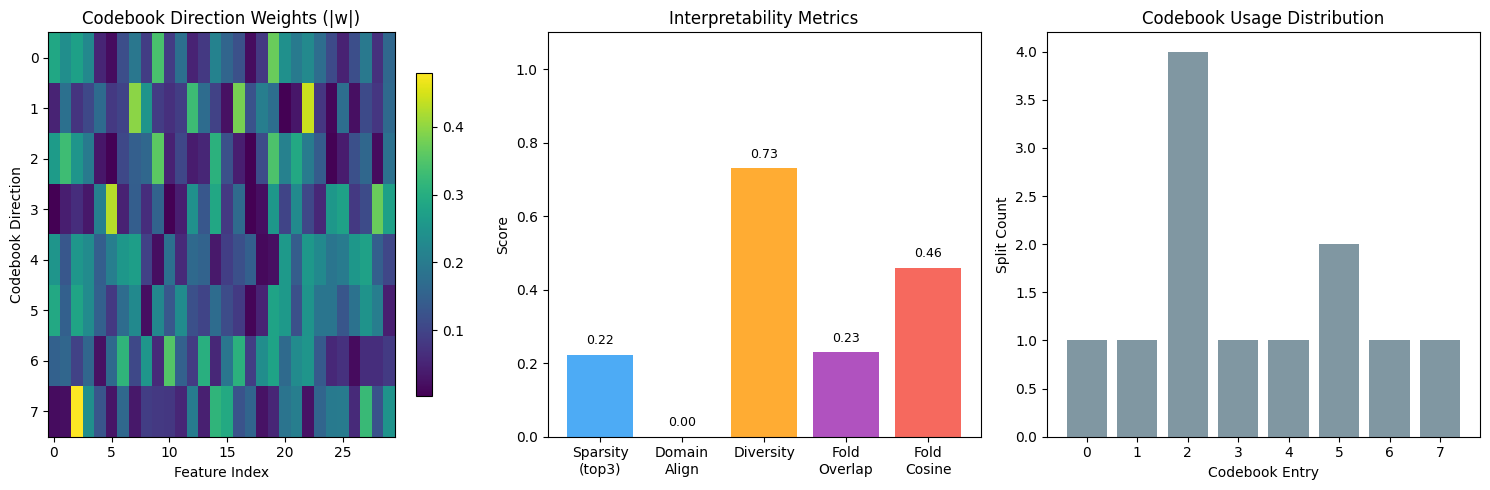


Figure saved to interpretability_results.png


In [11]:
# ── Summary Table ──
print(f"{'='*60}")
print(f"  Codebook-FIGS Interpretability Results: {ds_name}")
print(f"{'='*60}")
print(f"  Config: K={K}, max_rules={MAX_RULES}, "
      f"folds={actual_n_folds}, rounds={N_ALTERNATION_ROUNDS}")
print(f"  Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"{'─'*60}")
print(f"  {'Metric':<35} {'Value':>15}")
print(f"{'─'*60}")
print(f"  {'Sparsity (top-3 conc.)':<35} {sparsity['mean_top3_concentration']:>15.3f}")
print(f"  {'Sparsity (Gini)':<35} {sparsity['mean_gini']:>15.3f}")
print(f"  {'Domain Alignment (top-3 hit)':<35} {domain_align['mean_top3_hit_rate']:>15.3f}")
print(f"  {'Active Codebook Size':<35} {usage_info['active_codebook_size']:>15d}")
print(f"  {'Usage Uniformity':<35} {avg_uniformity:>15.3f}")
print(f"  {'FIGS Baseline Features':<35} {figs_uf_mean:>15d}")
print(f"  {'Compression Ratio':<35} {complexity['compression_ratio']:>15.1f}")
print(f"  {'Effective Rank':<35} {avg_erank:>15.2f}")
print(f"  {'Diversity Score':<35} {diversity['diversity_score']:>15.3f}")
print(f"  {'Cross-Fold Top-3 Overlap':<35} {stability['mean_top3_feature_overlap']:>15.3f}")
print(f"  {'Cross-Fold Cosine Stability':<35} {stability['mean_cosine_stability']:>15.3f}")
print(f"{'─'*60}")
print(f"  Verdict: {verdict}")
print()

# ── Semantic Labels ──
print("Codebook Direction Labels:")
for lab in labels:
    print(f"  Direction {lab['direction_idx']}: {lab['semantic_name']}")
    print(f"    {lab['formula']}")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Codebook heatmap
ax = axes[0]
im = ax.imshow(np.abs(primary_codebook), aspect='auto', cmap='viridis')
ax.set_xlabel("Feature Index")
ax.set_ylabel("Codebook Direction")
ax.set_title("Codebook Direction Weights (|w|)")
ax.set_yticks(range(K))
plt.colorbar(im, ax=ax, shrink=0.8)

# Plot 2: Metric radar-style bar chart
ax = axes[1]
metric_names = ["Sparsity\n(top3)", "Domain\nAlign", "Diversity", "Fold\nOverlap", "Fold\nCosine"]
metric_values = [
    sparsity['mean_top3_concentration'],
    domain_align['mean_top3_hit_rate'],
    diversity['diversity_score'],
    stability['mean_top3_feature_overlap'],
    stability['mean_cosine_stability'],
]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = ax.bar(metric_names, metric_values, color=colors, alpha=0.8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Interpretability Metrics")
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Usage distribution
ax = axes[2]
usage_counts = usage_info["usage_counts"]
ax.bar(range(K), usage_counts, color='#607D8B', alpha=0.8)
ax.set_xlabel("Codebook Entry")
ax.set_ylabel("Split Count")
ax.set_title("Codebook Usage Distribution")
ax.set_xticks(range(K))

plt.tight_layout()
plt.savefig("interpretability_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved to interpretability_results.png")